In [1]:
from pathlib import Path
import sys, os

scriptPath = Path.cwd()
parentPath = scriptPath.parent
dataPath = parentPath / 'data'
srcPath = parentPath / 'src'
modelPath = parentPath / 'models'
savePath = parentPath / 'results'
plotPath = parentPath / 'plots'

sys.path.append(srcPath.as_posix())

## Load the data

In [2]:
import cv2
import torch

class CELLClassifier(torch.utils.data.Dataset):
    '''
    Custom dataset for handling the data for training the linear classifier
    '''
    def __init__(self, data, target, transform, target_transform, image_size):
        super().__init__()
        self.data = data.reshape(-1, 100, 100)
        self.target = target.long()
        self.transform = transform #transformation applied for training the linear classifier
        self.target_transform = target_transform
        self.down_samp = cv2.resize
        self.downscale_imgs(image_size)

    def __getitem__(self, idx):
        with torch.no_grad():
            if self.transform is not None:
                upscaled_im = self.transform(self.data[idx])
            else:
                upscaled_im = self.data[idx]

            if self.target_transform is not None:
                target = self.target_transform(self.target[idx])
            else:
                target = self.target[idx]

            return upscaled_im.float(), target # we return the two views of the input as a list - no need for a target here...

    def __len__(self):
        return len(self.target)

    def downscale_imgs(self, image_size):
        '''
        Function to upscale imgs first for putting them on gpus directly and avoid cpu <-> gpu transfert during train_test_error_linear_Class_vs_fixed_random_proj.pdfining
        '''
        downscaled_imgs = torch.empty(self.data.size(0), image_size**2)
        for idx, data in enumerate(self.data):
            downscaled_imgs[idx] = torch.from_numpy(self.down_samp(data.numpy(), (image_size,image_size), interpolation= cv2.INTER_LINEAR)).reshape(-1)

        self.data = downscaled_imgs


In [3]:
import numpy as np
test_data = np.load(dataPath / 'test_cell3k.npz')

In [4]:
test_data_cell, test_labels_cell = \
torch.from_numpy(test_data['data']).type(torch.FloatTensor), torch.from_numpy(test_data['labels'])

In [5]:
image_size = 100
input_size = image_size**2
num_classes = 3
test_batch_size = 128

test_dataset = CELLClassifier(test_data_cell, test_labels_cell,transform = None, target_transform = None, image_size = image_size)

test_sampler = torch.utils.data.BatchSampler(\
                                             torch.utils.data.SequentialSampler(range(test_labels_cell.shape[0])), \
                                             batch_size=test_batch_size, drop_last=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_sampler=test_sampler)

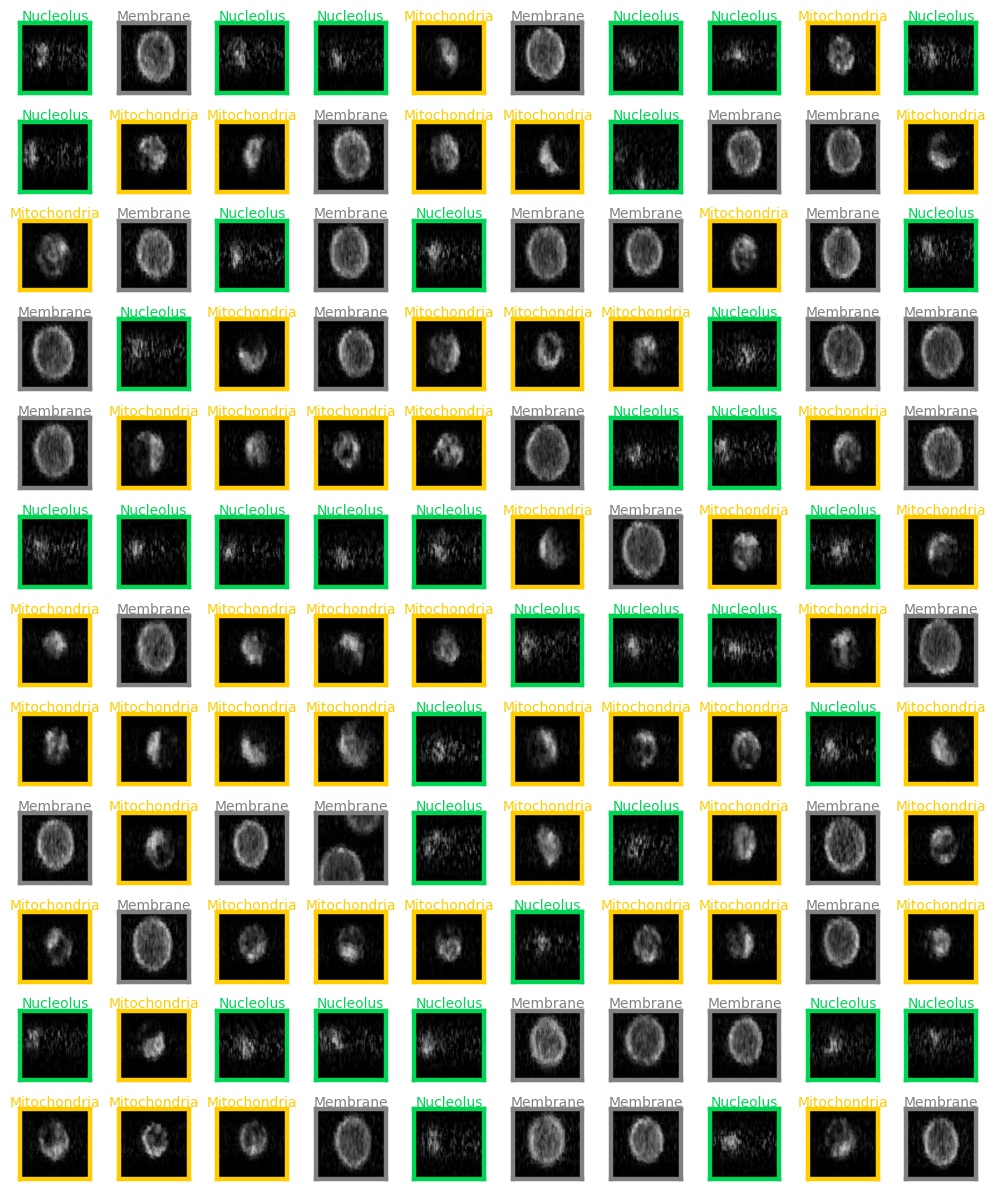

In [6]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['axes.titlepad'] = 0 
np.random.seed(10)

nx, ny = 12,10
fig, axs = plt.subplots(nx, ny, figsize=(ny, nx))
namestr = ['Membrane', 'Nucleolus', 'Mitochondria']
colors = ['gray','#00d455','#ffcc00']
for i in range(nx):
    for j in range(ny):
        ax = axs[i, j]
        ind = np.random.randint(test_data['data'].shape[0])
        im = ax.imshow(test_data['data'][ind].reshape(100,100), vmin=0, vmax=1.2,cmap='binary_r',aspect='equal')
            
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines:
            ax.spines[sp].set_color(colors[test_data['labels'][ind]])
            ax.spines[sp].set_linewidth(3.2)

        ax.set_title(f'{namestr[test_data['labels'][ind]]}',fontsize=10,color=colors[test_data['labels'][ind]])

plt.tight_layout()

## Load the models

In [7]:
from PANS_linear import PANS_active

device = 'cpu'
thePath = modelPath / 'cell'

models = {}
dfs = []
for f in os.listdir(thePath):
    if f.startswith(f'Cell55k5k_N'):
        N = int(f.split('_')[1][1:])
        dfs.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_active(n_input=input_size, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(thePath / f, map_location=device))
        model.to(device)
        model.eval()
        models[N] = model

dfs.sort()
dfs

16 Cell55k5k_N16_fc[512].pth
3 Cell55k5k_N3_fc[512].pth
10 Cell55k5k_N10_fc[512].pth
6 Cell55k5k_N6_fc[512].pth
32 Cell55k5k_N32_fc[512].pth


[3, 6, 10, 16, 32]

## Simulation results

In [8]:
import pandas as pd

n_T = 100
temp_results = []

for dcr in [0,0.01,0.05,0.1]:
    print('\nDark Count Rate:\t',dcr)

    for df in dfs:
        model = models[df]

        photon_count = 0
        acc_arr = np.zeros((n_T))
        for data, target in test_loader:
            data = data.to(device).reshape(data.shape[0],-1)
            target = target.to(device)
            
            photon_count += model.get_acts(data).sum().item()+df*dcr*data.shape[0]

            for j in range(n_T):
                output = model.robust_test(data,dcr=dcr,n_rep=1)
                pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
                correct = pred.eq(target.data.view_as(pred)).cpu().sum()
                acc_arr[j] += correct
            # break

        acc_arr = acc_arr / float(len(test_dataset))
        photon_count = photon_count / float(len(test_dataset))
        mean_acc = 100. * acc_arr.mean()
        std_dev = 100. * acc_arr.std()

        # append the results to DataFrame
        temp_results.append({'d_f': df, 'dcr':dcr, 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': photon_count})

        print(f"Photon count {photon_count:.4g} \t{np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}% (dcr {dcr}, repeat {n_T})")

results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)



Dark Count Rate:	 0
Photon count 1.545 	80.11 ± 0.70% (dcr 0, repeat 100)
Photon count 3.443 	86.15 ± 0.56% (dcr 0, repeat 100)
Photon count 5.915 	91.42 ± 0.43% (dcr 0, repeat 100)
Photon count 9.358 	93.88 ± 0.39% (dcr 0, repeat 100)
Photon count 18.25 	97.04 ± 0.28% (dcr 0, repeat 100)

Dark Count Rate:	 0.01
Photon count 1.567 	79.79 ± 0.71% (dcr 0.01, repeat 100)
Photon count 3.521 	85.77 ± 0.58% (dcr 0.01, repeat 100)
Photon count 6.011 	91.23 ± 0.46% (dcr 0.01, repeat 100)
Photon count 9.57 	93.84 ± 0.38% (dcr 0.01, repeat 100)
Photon count 18.44 	96.92 ± 0.29% (dcr 0.01, repeat 100)

Dark Count Rate:	 0.05
Photon count 1.704 	78.52 ± 0.66% (dcr 0.05, repeat 100)
Photon count 3.757 	84.65 ± 0.60% (dcr 0.05, repeat 100)
Photon count 6.423 	90.50 ± 0.58% (dcr 0.05, repeat 100)
Photon count 10.2 	93.29 ± 0.42% (dcr 0.05, repeat 100)
Photon count 19.84 	96.81 ± 0.28% (dcr 0.05, repeat 100)

Dark Count Rate:	 0.1
Photon count 1.841 	76.74 ± 0.73% (dcr 0.1, repeat 100)
Photon count 4

In [9]:
results_df.to_pickle(savePath / 'cell_active_sim.npy')
results_df

,d_f,dcr,mean_accuracy,std_dev,det_photon_count
0,3,0.00,80.107667,0.702596,1.545000
1,6,0.00,86.147667,0.556322,3.443333
2,10,0.00,91.416333,0.428991,5.915000
3,16,0.00,93.875333,0.388319,9.358333
4,32,0.00,97.042000,0.275545,18.246333
5,3,0.01,79.788000,0.711923,1.567000
6,6,0.01,85.771667,0.583388,3.521000
7,10,0.01,91.225333,0.455732,6.011333
8,16,0.01,93.838667,0.378996,9.569667
9,32,0.01,96.924333,0.290741,18.438000


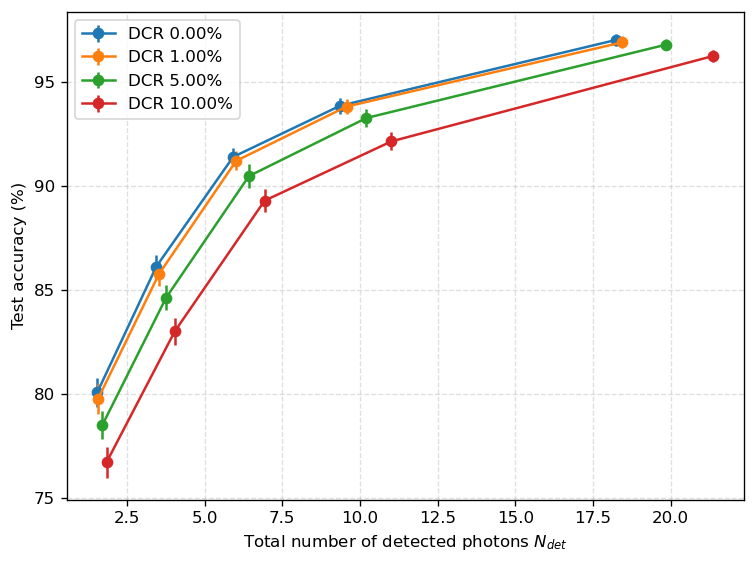

In [10]:
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

for dcr in results_df['dcr'].unique():
    the_df = results_df[results_df['dcr'] == dcr].sort_values('d_f')
    plt.errorbar(the_df['det_photon_count'],the_df['mean_accuracy'],yerr=the_df['std_dev'],fmt='-o',label=f'DCR {dcr*100:.2f}%')

plt.xlabel(r'Total number of detected photons $N_{det}$')
plt.ylabel('Test accuracy (%)')

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()